# Notebook of the results section

**All plots in the report can be reproduced here**

To save the plots as pgf figures, you will need a working latex distribution
with those apt packages installed

```bash
sudo apt install dvipng cm-super texlive-fonts-recommended
!sudo apt-get install texlive-latex-recommended
!sudo apt install texlive-latex-extra
!sudo apt install texlive-xetex
!sudo apt install ttf-mscorefonts-installer
```


In [2]:
from __future__ import annotations
from pathlib import Path

from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from sklearn.decomposition import PCA
from wandb.apis.public import Run

import wandb
import os
import pandas as pd
import scienceplots  # noqa: F401
from typing import cast
import json
import seaborn as sns
from matplotlib.colors import LogNorm
import geopandas as gpd


api = wandb.Api()


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\SSI63\_netrc.


In [3]:
plt.style.use(["science", "grid", "pgf"])
plt.rcParams.update(
    {
        "font.family": "serif",
        "text.usetex": True,
        "pgf.rcfonts": False,
        "pgf.preamble": "\n".join(
            [
                r"\usepackage{fontspec}",
                r"\usepackage{unicode-math}",
                r"\setmainfont{Times New Roman}",
                r"\usepackage{siunitx}",
            ]
        ),
    }
)


In [4]:
wandb.login()


wandb: Currently logged in as: maxerbox (maxerbox-org) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [5]:
output_dir = "../report/figures"
os.makedirs(output_dir, exist_ok=True)
GOLDEN_RATIO = (9, 5)

### Metrics over training epochs for the validation fold


In [ ]:
test_tf_events[0]


In [ ]:
def plot_val_train_metric(*runs: Run, tf_runs_df: list[pd.DataFrame]):
    # ---- mIoU plot ----
    _, ax_miou = plt.subplots(figsize=GOLDEN_RATIO)

    for run in runs:
        name = run.name
        history_df: pd.DataFrame = cast(pd.DataFrame, run.history())
        eval_data = history_df[["epoch", "val/mIoU_epoch"]].dropna()

        ax_miou.plot(
            eval_data["epoch"],
            eval_data["val/mIoU_epoch"],
            marker="o",
            markersize=4,
            linewidth=1.5,
            label=name,
        )
    for df in tf_runs_df:
        ax_miou.plot(
            df["val/miou"] / 100,
            marker="o",
            markersize=4,
            linewidth=1.5,
            label=df.Name,
        )

    ax_miou.set_xlabel("Epoch")
    ax_miou.set_ylabel("mIoU")
    ax_miou.set_title("Validation mIoU over training epochs")
    ax_miou.grid(True, alpha=0.3)
    ax_miou.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "val_train_miou_all_runs.pdf"), backend="pgf")
    plt.show()

    # ---- F1 Macro plot ----
    _, ax_f1 = plt.subplots(figsize=GOLDEN_RATIO)

    for run in runs:
        name = run.name
        history_df: pd.DataFrame = cast(pd.DataFrame, run.history())
        eval_data = history_df[["epoch", "val/F1_macro_epoch"]].dropna()

        ax_f1.plot(
            eval_data["epoch"],
            eval_data["val/F1_macro_epoch"],
            marker="o",
            markersize=4,
            linewidth=1.5,
            label=name,
        )

    ax_f1.set_xlabel("Epoch")
    ax_f1.set_ylabel("F1 Macro")
    ax_f1.set_title("Validation F1 Macro over training epochs")
    ax_f1.grid(True, alpha=0.3)
    ax_f1.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "val_train_f1_all_runs.pdf"), backend="pgf")
    plt.show()


In [ ]:
plot_val_train_metric(*train_runs, tf_runs_df=train_tf_events)


### Summary metrics (F1 macro, IoU macro, etc.) for the whole test fold


In [ ]:
import math


def export_test_run_metrics_to_latex(
    *runs: Run,
    tests_df: list[pd.DataFrame] = [],
    caption: str = "Test metrics",
    label: str = "tab:test_metrics",
    output_filename: str = "test_metrics_table.tex",
):
    """Export test metrics to LaTeX table with bold formatting for highest values."""
    metrics = {}
    for run in runs:
        run_metrics = run.summary
        metrics[run.name] = {
            "mIoU": run_metrics.get("test/mIoU_epoch", "N/A"),
            "F1 Macro": run_metrics.get("test/F1_macro_epoch", "N/A"),
            "Overall accuracy": run_metrics.get("test/accuracy_epoch", "N/A"),
        }
    for df in tests_df:
        metrics[df.Name] = {
            "mIoU": df["test/miou"].iloc[-1] / 100
            if "test/miou" in df.columns
            else math.nan,
            "F1 Macro": df["test/f1_macro"].iloc[-1] / 100
            if "test/f1_macro" in df.columns
            else math.nan,
            "Overall accuracy": df["test/acc"].iloc[-1] / 100
            if "test/acc" in df.columns
            else math.nan,
        }

    df = pd.DataFrame(metrics).T

    # Format with bold for max values in each column
    def format_with_bold(df_to_format: pd.DataFrame) -> str:
        latex_str = df_to_format.to_latex(
            float_format="%.4f",
            caption=caption,
            label=label,
            escape=False,  # Don't escape special characters
        )

        # Find max value for each metric column and bold it
        for col in df_to_format.columns:
            # Skip non-numeric columns
            if df_to_format[col].dtype not in [np.float64, np.int64, float, int]:
                continue

            max_val = df_to_format[col].max()
            if pd.notna(max_val):
                # Format the max value
                max_str = f"{max_val:.4f}"
                bold_max_str = r"\textbf{" + max_str + "}"
                # Replace the first occurrence of the max value in the table
                latex_str = latex_str.replace(max_str, bold_max_str, 1)

        return latex_str

    df.index = df.index.str.replace("_", r"\_", regex=False)
    df = df.fillna("-")
    latex_output = format_with_bold(df)

    # Write to file
    with open(os.path.join(output_dir, output_filename), "w") as f:
        f.write(latex_output)


def export_test_run_f1_per_class_to_latex(
    *runs: Run,
    caption: str = "Test F1 per class",
    label: str = "tab:test_f1_per_class",
    output_filename: str = "test_f1_per_class_table.tex",
    resize_to_textwidth: bool = True,
):
    """Export test F1 per class to a LaTeX table (bold best run per class)."""
    # Metrics are logged as: test/F1_<class name> (no background/void).
    class_names = [PASTIS_LABEL_NAMES[i] for i in range(1, 19)]

    data: dict[str, dict[str, float]] = {}
    for run in runs:
        run_metrics = run.summary
        data[run.name] = {
            cls: run_metrics.get(f"test/F1_{cls}", np.nan) for cls in class_names
        }

    # Rows=runs, Cols=classes
    df = pd.DataFrame(data)
    df_num = df.apply(pd.to_numeric, errors="coerce")

    # Format numbers and bold the best run for each class (column-wise maximum).
    df_str = df_num.map(lambda x: "N/A" if pd.isna(x) else f"{x:.4f}")
    for cls in df_num.columns:
        max_val = df_num[cls].max(skipna=True)
        if pd.isna(max_val):
            continue
        for run_name in df_num.index:
            v = df_num.loc[run_name, cls]
            if pd.notna(v) and np.isclose(v, max_val):
                df_str.loc[run_name, cls] = (
                    r"\textbf{" + df_str.loc[run_name, cls] + "}"
                )
    df_str.columns = [c.replace("_", r"\_") for c in df_str.columns]
    latex_output = df_str.to_latex(caption=caption, label=label, escape=False)
    if resize_to_textwidth:
        latex_output = latex_output.replace(
            r"\begin{tabular}{",
            r"\resizebox{\textwidth}{!}{\begin{tabular}{",
            1,
        )
        latex_output = latex_output.replace(r"\end{tabular}", r"\end{tabular}}", 1)

    with open(os.path.join(output_dir, output_filename), "w") as f:
        f.write(latex_output)


In [ ]:
export_test_run_metrics_to_latex(*test_runs, tests_df=test_tf_events)
export_test_run_f1_per_class_to_latex(
    *test_runs,
    caption="Test F1 per class",
    label="tab:test_f1_per_class",
    output_filename="test_f1_per_class_table.tex",
)

### Summary metrics for scarce data (30 patches per fold)


In [ ]:
export_test_run_metrics_to_latex(
    *test_runs_scarce,
    caption="Test metrics with scarce data (30 patches per fold)",
    label="tab:test_metrics_scarce",
    output_filename="test_metrics_scarce_table.tex",
)

### Confusion matrix


In [ ]:
def export_confusion_matrix_test_runs(*runs: Run):
    for run in runs:
        name = run.name
        confmat_path = run.summary["confmat_test_table"]["path"]
        table = json.load(run.file(confmat_path).download(exist_ok=True))
        df = pd.DataFrame(table["data"], columns=table["columns"])
        df["nPredictions"] = df["nPredictions"].astype(int)
        # Colums = Actual, predicted, nPredictions

        cm = df.pivot(
            index="Actual", columns="Predicted", values="nPredictions"
        ).fillna(0)
        fig, ax = plt.subplots(figsize=(18, 16))
        cm_safe = cm.replace(0, 1)
        sns.heatmap(
            cm_safe,
            cmap="viridis",
            annot=cm,
            fmt="d",
            ax=ax,
            norm=LogNorm(vmin=1, vmax=cm.values.max()),  # log scale
            cbar_kws={"label": "nPredictions (log scale)"},
        )

        ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha="right")
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

        ax.set_title("Confusion Matrix (log scale)")
        plt.tight_layout()
        plt.show()
        fig.savefig(
            os.path.join(output_dir, f"confusion_matrix_{name}.pdf"), backend="pgf"
        )

In [ ]:
export_confusion_matrix_test_runs(*test_runs)

In [ ]:
@dataclass(frozen=True)
class _PredictionPayload:
    patch_id: int
    embedding_hwd: np.ndarray  # (H,W,D) or None if not available
    ground_truth_hw: np.ndarray  # (H,W) in 0..17 (+ ignore) OR 0..19 (PASTIS)
    prediction_hw: np.ndarray  # (H,W) in 0..17 OR 1..18
    ignore_mask_hw: np.ndarray  # (H,W) bool, True means background/void/ignore


def _get_predictions_table_df(run: Run) -> pd.DataFrame:
    arts = list(run.logged_artifacts())
    candidates = [a for a in arts if "test_predictions_final" in a.name]
    if not candidates:
        raise RuntimeError(
            f"Could not find a 'test_predictions_final' artifact for run {run.path}."
        )
    artifact = run.use_artifact(candidates[-1])
    table = artifact.get("test_predictions_final_epoch")
    return table.get_dataframe()  # type: ignore


def _normalize_gt_pred_masks(
    ground_truth_hw: np.ndarray, prediction_hw: np.ndarray
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    gt = np.asarray(ground_truth_hw)
    pred = np.asarray(prediction_hw)
    if gt.min() == 0 and gt.max() == 19:
        ignore_mask = (gt == 0) | (gt == 19)
        gt_cls = gt.astype(np.int64) - 1
    elif gt.max() == 18:
        ignore_mask = gt == 18
        gt_cls = gt.astype(np.int64)
    else:
        ignore_mask = np.zeros_like(gt, dtype=bool)
        gt_cls = gt.astype(np.int64)
    if pred.min() >= 1 and pred.max() <= 18:
        pred_cls = pred.astype(np.int64) - 1
    else:
        pred_cls = pred.astype(np.int64)
    return gt_cls, pred_cls, ignore_mask


def _compute_embedding_pca_rgb(
    embedding_hwd: np.ndarray, ignore_mask_hw: np.ndarray, seed: int = 0
) -> np.ndarray:
    emb = np.asarray(embedding_hwd, dtype=np.float32)
    h, w, d = emb.shape
    x = emb.reshape(-1, d)
    valid = (~ignore_mask_hw).reshape(-1)
    x_valid = x[valid]
    if x_valid.size == 0:
        x_valid = x
    n_fit = min(20_000, x_valid.shape[0])
    rng = np.random.default_rng(seed)
    fit_idx = rng.choice(x_valid.shape[0], size=n_fit, replace=False)
    pca = PCA(n_components=3, random_state=seed)
    pca.fit(x_valid[fit_idx])
    z = pca.transform(x).reshape(h, w, 3)
    rgb = np.empty_like(z, dtype=np.float32)
    for c in range(3):
        chan = z[..., c]
        lo, hi = np.nanpercentile(chan[~ignore_mask_hw], [2, 98])
        if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
            lo, hi = float(chan.min()), float(chan.max())
        rgb[..., c] = np.clip((chan - lo) / (hi - lo + 1e-6), 0.0, 1.0)
    rgb[ignore_mask_hw] = np.nan
    return rgb


def plot_prediction_map(
    *runs: Run,
    patch_id: int | None = None,
    alpha: float = 1.0,
    pca_alpha: float = 1.0,
    seed: int = 0,
    basemap_source=cx.providers.Esri.WorldImagery,  # type: ignore
    basemap_attribution: str | None = "© Esri",
    basemap_attribution_size: int = 6,
    title_suffix: str = "",
    output_filename_prefix: str = "prediction_map",
) -> None:
    dfs = [_get_predictions_table_df(run) for run in runs]
    if patch_id is None:
        patch_id = int(dfs[0].iloc[0]["patch_id"])
    patch_id_int = int(patch_id)
    nrows = len(runs)
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=3,
        figsize=(18, 5.2 * nrows),
        squeeze=False,
        gridspec_kw={"wspace": 0.02, "hspace": 0.10},
    )
    base_colors = list(plt.get_cmap("tab20").colors[:18])  # type: ignore
    seg_cmap = ListedColormap(base_colors, name="pastis_18")
    seg_cmap.set_bad((0, 0, 0, 0))
    meta = dataset.pastis_dataset.meta_patch
    patch_geom = meta.loc[patch_id_int].geometry
    patch_geom_3857 = gpd.GeoSeries([patch_geom], crs=meta.crs).to_crs(epsg=3857)
    xmin, ymin, xmax, ymax = patch_geom_3857.total_bounds
    extent = (xmin, xmax, ymin, ymax)
    class_legend_handles: list[Patch] | None = None

    for row_i, (run, df) in enumerate(zip(runs, dfs, strict=True)):
        sub = df[df["patch_id"].astype(int) == patch_id_int]
        if len(sub) == 0:
            sub = df.iloc[[0]]
        r = sub.iloc[0]
        gt_cls, pred_cls, ignore_mask = _normalize_gt_pred_masks(
            r["ground_truth_mask"], r["prediction_mask"]
        )
        # Handle missing embedding (e.g., UTAE or NA)
        if "embedding" in r and r["embedding"] is not None:
            embedding_hwd = np.asarray(r["embedding"])
            has_embedding = True
        else:
            embedding_hwd = None
            has_embedding = False
        payload = _PredictionPayload(
            patch_id=int(r["patch_id"]),
            embedding_hwd=embedding_hwd,
            ground_truth_hw=gt_cls,
            prediction_hw=pred_cls,
            ignore_mask_hw=ignore_mask,
        )
        gt_labels = sorted(
            int(x) for x in np.unique(payload.ground_truth_hw[~payload.ignore_mask_hw])
        )
        pred_labels = sorted(
            int(x) for x in np.unique(payload.prediction_hw[~payload.ignore_mask_hw])
        )
        labels_present = sorted(set(gt_labels) | set(pred_labels))
        if class_legend_handles is None:
            class_legend_handles = [
                Patch(
                    facecolor=seg_cmap(lbl),
                    edgecolor="none",
                    label=PASTIS_LABEL_NAMES[lbl + 1],
                )
                for lbl in labels_present
                if (lbl + 1) in PASTIS_LABEL_NAMES
            ]
        # --- PCA panel (now first) ---
        ax_pca = axes[row_i, 0]
        ax_pca.set_xlim(xmin, xmax)
        ax_pca.set_ylim(ymin, ymax)
        cx.add_basemap(
            ax_pca,
            source=basemap_source,
            attribution=basemap_attribution,
            attribution_size=basemap_attribution_size,
            reset_extent=False,
        )
        if has_embedding:
            rgb = _compute_embedding_pca_rgb(
                payload.embedding_hwd, payload.ignore_mask_hw, seed=seed
            )
            ax_pca.imshow(rgb, extent=extent, origin="upper", alpha=pca_alpha)
        else:
            # 1. Use a fully transparent dummy image to force the correct aspect ratio
            dummy_transparent = np.zeros((2, 2, 4))
            ax_pca.imshow(dummy_transparent, extent=extent, origin="upper")

            # 2. Perfectly center the "NA" text using Axes coordinates
            ax_pca.text(
                0.5,
                0.5,
                "NA",
                color="red",
                fontsize=48,
                ha="center",
                va="center",
                fontweight="bold",
                transform=ax_pca.transAxes,
            )
        ax_pca.set_axis_off()
        # --- Prediction panel (now second) ---
        ax_pred = axes[row_i, 1]
        ax_pred.set_xlim(xmin, xmax)
        ax_pred.set_ylim(ymin, ymax)
        cx.add_basemap(
            ax_pred,
            source=basemap_source,
            attribution=basemap_attribution,
            attribution_size=basemap_attribution_size,
            reset_extent=False,
        )
        pred_masked = np.ma.masked_where(payload.ignore_mask_hw, payload.prediction_hw)
        ax_pred.imshow(
            pred_masked,
            extent=extent,
            origin="upper",
            cmap=seg_cmap,
            vmin=0,
            vmax=17,
            alpha=alpha,
            interpolation="nearest",
        )
        ax_pred.set_axis_off()
        # --- Ground truth panel (now third) ---
        ax_gt = axes[row_i, 2]
        ax_gt.set_xlim(xmin, xmax)
        ax_gt.set_ylim(ymin, ymax)
        cx.add_basemap(
            ax_gt,
            source=basemap_source,
            attribution=basemap_attribution,
            attribution_size=basemap_attribution_size,
            reset_extent=False,
        )
        gt_masked = np.ma.masked_where(payload.ignore_mask_hw, payload.ground_truth_hw)
        ax_gt.imshow(
            gt_masked,
            extent=extent,
            origin="upper",
            cmap=seg_cmap,
            vmin=0,
            vmax=17,
            alpha=alpha,
            interpolation="nearest",
        )
        ax_gt.set_axis_off()
    axes[0, 0].set_title("Embedding PCA", fontsize=12, pad=20)
    axes[0, 1].set_title("Predicted label", fontsize=12, pad=20)
    axes[0, 2].set_title("Ground truth", fontsize=12, pad=20)
    title = f"Patch {patch_id_int}"
    if title_suffix:
        title += f" {title_suffix}"
    fig.suptitle(title, y=0.995, fontsize=14, ha="center")
    fig.subplots_adjust(left=0.02, right=0.98, top=0.92, bottom=0.12)
    legend_handles_all = []
    pca_legend_handles = [
        Patch(facecolor="red", edgecolor="none", label="PC1 (Red)"),
        Patch(facecolor="green", edgecolor="none", label="PC2 (Green)"),
        Patch(facecolor="blue", edgecolor="none", label="PC3 (Blue)"),
    ]
    if class_legend_handles:
        legend_handles_all = pca_legend_handles + class_legend_handles
        ncol = 7
        fig.legend(
            handles=legend_handles_all,
            loc="lower center",
            bbox_to_anchor=(0.5, 0.01),
            frameon=False,
            fontsize="small",
            ncol=ncol,
        )
    fig.canvas.draw()
    for row_i, run in enumerate(runs):
        row_axes = axes[row_i, :]
        left = row_axes[0].get_position().x0
        right = row_axes[-1].get_position().x1
        bottom = min(ax.get_position().y0 for ax in row_axes)
        fig.text(
            (left + right) / 2,
            bottom - 0.012,
            str(run.name),
            ha="center",
            va="top",
            fontsize=11,
        )
    plt.show()
    fig.savefig(
        os.path.join(output_dir, f"{output_filename_prefix}_patch_{patch_id_int}.pdf"),
        backend="pgf",
    )


In [ ]:
plot_prediction_map(*preview_runs)


### Prediction maps for scarce data (30 patches per fold)


In [ ]:
plot_prediction_map(
    *preview_runs_scarce,
    title_suffix="(Scarce data: 30 patches/fold)",
    output_filename_prefix="prediction_map_scarce",
)

## Pointcloud JEPA — eval loss & probe accuracy by epoch

Comparison of the 6 pointcloud runs (rotate = none / z / so3), with and without
the transformer encoder (ablation). Each run is fetched from W&B; the two plots
below show **eval loss** and **linear-probe accuracy** as a function of the
training epoch. Figures are exported as PGF-compatible PDF.


In [6]:
# AVEC TRANSFORMER
pc_tf_none: Run = api.run("maxerbox-org/eb_jepa/kez6azi1")  # rotate none
pc_tf_z: Run = api.run("maxerbox-org/eb_jepa/b8jv3tqa")  # rotate z
pc_tf_so3: Run = api.run("maxerbox-org/eb_jepa/frvpjlxm")  # rotate so3

# SANS TRANSFORMER (ablation)
pc_notf_none: Run = api.run("maxerbox-org/eb_jepa/hc2815h5")  # rotate none
pc_notf_z: Run = api.run("maxerbox-org/eb_jepa/gngqgzdn")  # rotate z
pc_notf_so3: Run = api.run("maxerbox-org/eb_jepa/zi6b6ryf")  # rotate so3

# Pretty labels for the legend
PC_RUN_LABELS = {
    pc_tf_none: r"Transformer \(rotate=none\)",
    pc_tf_z: r"Transformer \(rotate=z\)",
    pc_tf_so3: r"Transformer \(rotate=so3\)",
    pc_notf_none: r"No transformer \(rotate=none\)",
    pc_notf_z: r"No transformer \(rotate=z\)",
    pc_notf_so3: r"No transformer \(rotate=so3\)",
}
PC_RUNS: list[Run] = list(PC_RUN_LABELS.keys())


In [15]:
def plot_pointcloud_eval_loss(
    *runs: Run,
    labels: dict | None = None,
    output_filename: str = "pointcloud_eval_loss.pdf",
) -> None:
    """Plot eval/loss vs epoch for the pointcloud runs and export to PGF PDF."""
    fig, ax = plt.subplots(figsize=GOLDEN_RATIO)
    for run in runs:
        name = labels.get(run, run.name) if labels else run.name
        history_df: pd.DataFrame = cast(pd.DataFrame, run.history())
        if "eval/loss" not in history_df.columns:
            print(f"  [skip] {run.name}: no eval/loss column")
            continue
        eval_data = history_df[["epoch", "eval/loss"]].dropna()
        ax.plot(
            eval_data["epoch"],
            eval_data["eval/loss"],
            marker="o",
            markersize=3,
            linewidth=1.5,
            label=name,
        )
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Eval loss")
    ax.set_title("Eval loss over training epochs")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize="small", ncol=2)
    plt.tight_layout()
    fig.savefig(os.path.join(output_dir, output_filename), backend="pgf")
    plt.show()


def plot_pointcloud_probe_accuracy(
    *runs: Run,
    labels: dict | None = None,
    output_filename: str = "pointcloud_probe_accuracy.pdf",
) -> None:
    """Plot probe/accuracy vs epoch for the pointcloud runs and export to PGF PDF."""
    fig, ax = plt.subplots(figsize=GOLDEN_RATIO)
    for run in runs:
        name = labels.get(run, run.name) if labels else run.name
        history_df: pd.DataFrame = cast(pd.DataFrame, run.history())
        if "probe/accuracy" not in history_df.columns:
            print(f"  [skip] {run.name}: no probe/accuracy column")
            continue
        eval_data = history_df[["epoch", "probe/accuracy"]].dropna()
        ax.plot(
            eval_data["epoch"],
            eval_data["probe/accuracy"],
            marker="o",
            markersize=3,
            linewidth=1.5,
            label=name,
        )
    ax.set_xlabel("Epoch")
    ax.set_ylabel(r"Probe accuracy (\%)")
    ax.set_title("Linear-probe accuracy over training epochs")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize="small", ncol=2)
    plt.tight_layout()
    fig.savefig(os.path.join(output_dir, output_filename), backend="pgf")
    plt.show()


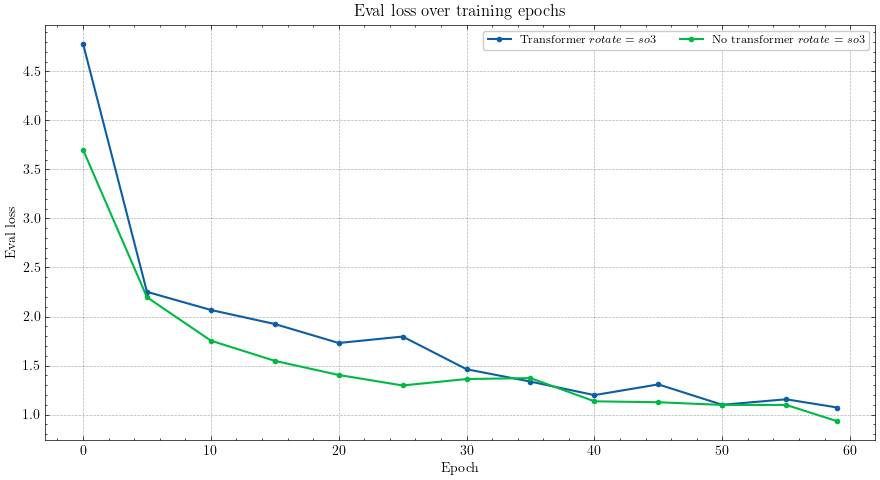

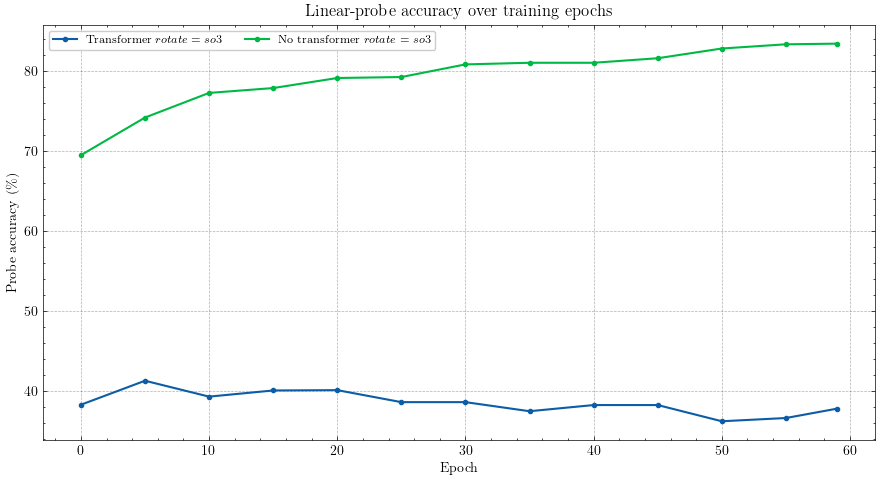

In [16]:
# Only so3 rotation: transformer vs no-transformer (ablation)
PC_SO3_LABELS = {
    pc_tf_so3: r"Transformer \(rotate=so3\)",
    pc_notf_so3: r"No transformer \(rotate=so3\)",
}
PC_SO3_RUNS: list[Run] = list(PC_SO3_LABELS.keys())

plot_pointcloud_eval_loss(*PC_SO3_RUNS, labels=PC_SO3_LABELS)
plot_pointcloud_probe_accuracy(*PC_SO3_RUNS, labels=PC_SO3_LABELS)


## Baseline vs Transformer — eval loss & probe accuracy

Same two metrics (eval loss, linear-probe accuracy) but comparing only the
**baseline** and the **transformer** runs (no ablation). Exported to separate
PGF PDFs.


In [9]:
# BASELINE
pc_base_none: Run = api.run("maxerbox-org/eb_jepa/xp34zxau")  # rotate none
pc_base_z: Run = api.run("maxerbox-org/eb_jepa/w1yowd1f")  # rotate z
pc_base_so3: Run = api.run("maxerbox-org/eb_jepa/w0usic1c")  # rotate so3

# Combined labels: baseline + transformer only (no ablation)
PC_BASE_TF_LABELS = {
    pc_base_none: r"Baseline \(rotate=none\)",
    pc_base_z: r"Baseline \(rotate=z\)",
    pc_base_so3: r"Baseline \(rotate=so3\)",
    pc_tf_none: r"Transformer \(rotate=none\)",
    pc_tf_z: r"Transformer \(rotate=z\)",
    pc_tf_so3: r"Transformer \(rotate=so3\)",
}
PC_BASE_TF_RUNS: list[Run] = list(PC_BASE_TF_LABELS.keys())


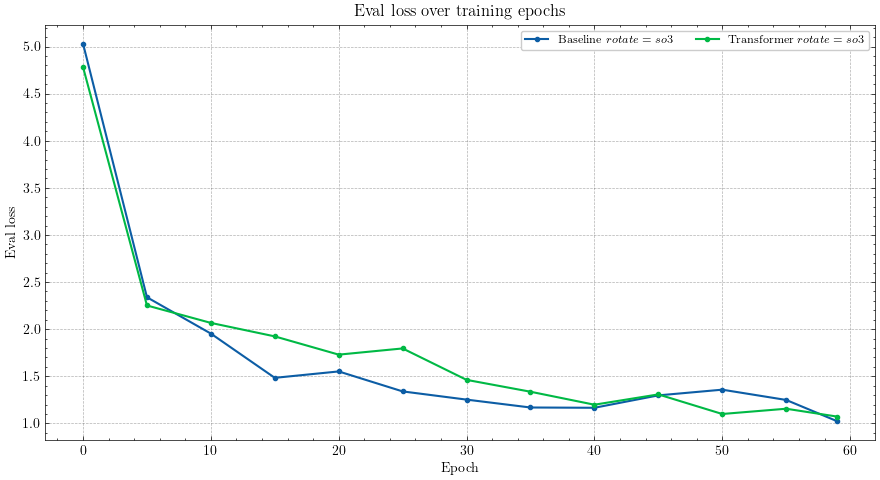

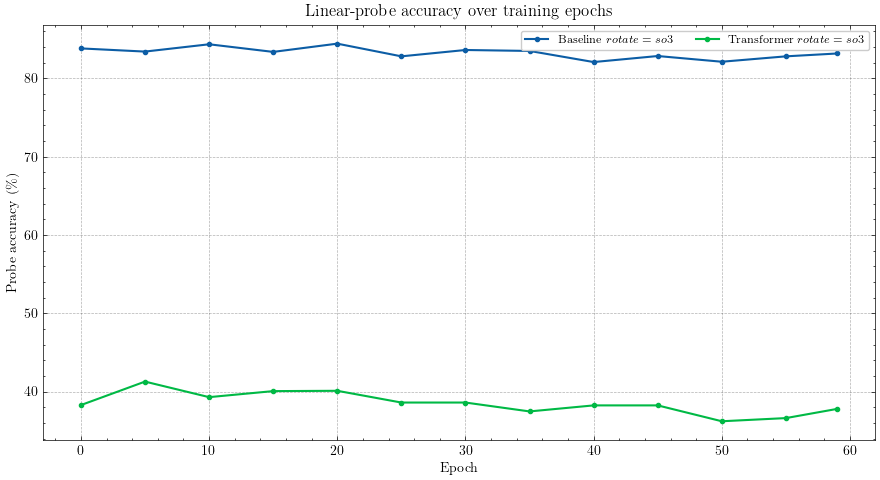

In [17]:
# Only so3 rotation: baseline vs transformer
PC_BASE_TF_SO3_LABELS = {
    pc_base_so3: r"Baseline \(rotate=so3\)",
    pc_tf_so3: r"Transformer \(rotate=so3\)",
}
PC_BASE_TF_SO3_RUNS: list[Run] = list(PC_BASE_TF_SO3_LABELS.keys())

plot_pointcloud_eval_loss(
    *PC_BASE_TF_SO3_RUNS,
    labels=PC_BASE_TF_SO3_LABELS,
    output_filename="pointcloud_eval_loss_baseline_vs_transformer.pdf",
)
plot_pointcloud_probe_accuracy(
    *PC_BASE_TF_SO3_RUNS,
    labels=PC_BASE_TF_SO3_LABELS,
    output_filename="pointcloud_probe_accuracy_baseline_vs_transformer.pdf",
)


## Transformer — eval loss by rotation setting

Eval loss for the transformer runs across the three rotation settings (none, z,
so3) to show how rotation augmentation affects convergence.


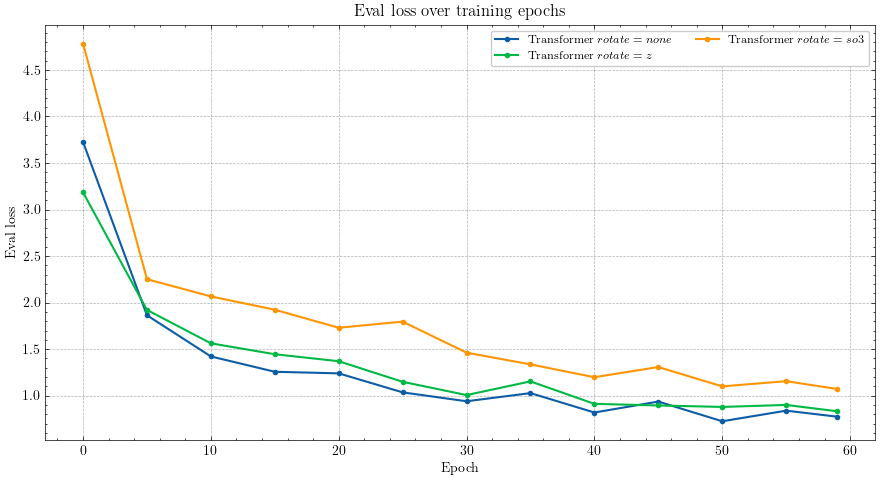

In [18]:
# Transformer only: eval loss for rotate none / z / so3
PC_TF_ROT_LABELS = {
    pc_tf_none: r"Transformer \(rotate=none\)",
    pc_tf_z: r"Transformer \(rotate=z\)",
    pc_tf_so3: r"Transformer \(rotate=so3\)",
}
PC_TF_ROT_RUNS: list[Run] = list(PC_TF_ROT_LABELS.keys())

plot_pointcloud_eval_loss(
    *PC_TF_ROT_RUNS,
    labels=PC_TF_ROT_LABELS,
    output_filename="pointcloud_eval_loss_transformer_rotations.pdf",
)


## Rotated probe accuracy (so3) — baseline vs transformer vs ablation

Linear-probe accuracy evaluated on **rotation-augmented test features** (the
`probe/rotated_accuracy` metric), for the three so3 runs. This shows how well
each model generalises when the test set is rotated relative to training.


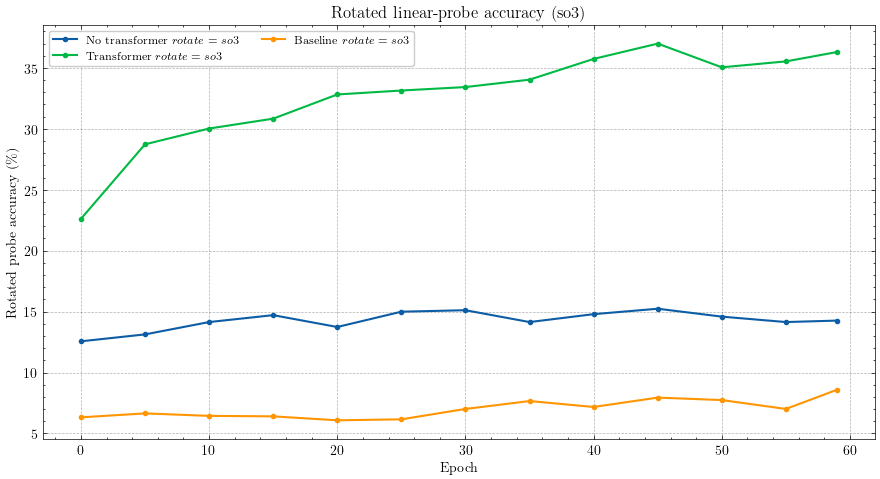

In [19]:
def plot_pointcloud_rotated_probe_accuracy(
    *runs: Run,
    labels: dict | None = None,
    output_filename: str = "pointcloud_rotated_probe_accuracy.pdf",
) -> None:
    """Plot probe/rotated_accuracy vs epoch and export to PGF PDF."""
    fig, ax = plt.subplots(figsize=GOLDEN_RATIO)
    for run in runs:
        name = labels.get(run, run.name) if labels else run.name
        history_df: pd.DataFrame = cast(pd.DataFrame, run.history())
        if "probe/rotated_accuracy" not in history_df.columns:
            print(f"  [skip] {run.name}: no probe/rotated_accuracy column")
            continue
        eval_data = history_df[["epoch", "probe/rotated_accuracy"]].dropna()
        ax.plot(
            eval_data["epoch"],
            eval_data["probe/rotated_accuracy"],
            marker="o",
            markersize=3,
            linewidth=1.5,
            label=name,
        )
    ax.set_xlabel("Epoch")
    ax.set_ylabel(r"Rotated probe accuracy (\%)")
    ax.set_title("Rotated linear-probe accuracy (so3)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize="small", ncol=2)
    plt.tight_layout()
    fig.savefig(os.path.join(output_dir, output_filename), backend="pgf")
    plt.show()


# so3 runs: no-transformer (ablation), transformer, baseline
PC_ROT_ACC_LABELS = {
    pc_notf_so3: r"No transformer \(rotate=so3\)",
    pc_tf_so3: r"Transformer \(rotate=so3\)",
    pc_base_so3: r"Baseline \(rotate=so3\)",
}
PC_ROT_ACC_RUNS: list[Run] = list(PC_ROT_ACC_LABELS.keys())

plot_pointcloud_rotated_probe_accuracy(
    *PC_ROT_ACC_RUNS,
    labels=PC_ROT_ACC_LABELS,
)


wandb:   1 of 1 files downloaded.  


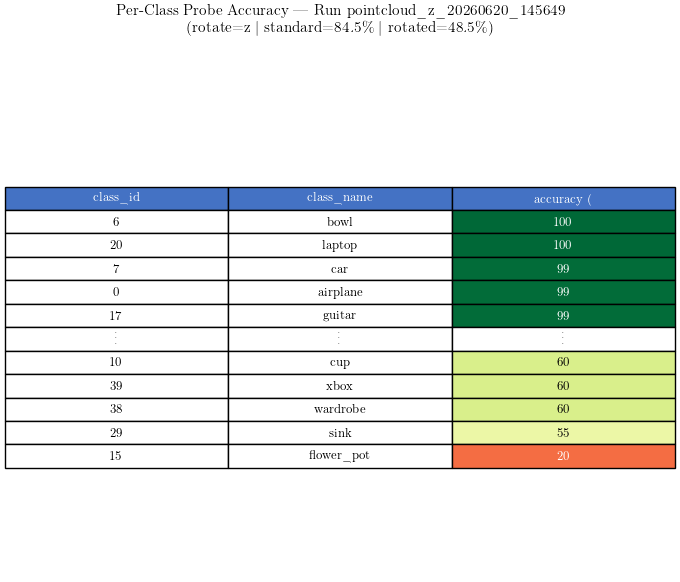

Saved: ../report/figures\pointcloud_per_class_accuracy_0cqj036c.jpg
Saved: ../report/figures\pointcloud_per_class_accuracy_0cqj036c.tex

\begin{table}
\caption{Per-class probe accuracy for run pointcloud_z_20260620_145649 (rotate=z). Standard=84.5\%, Rotated=48.5\%.}
\label{tab:per_class_accuracy_0cqj036c}
\begin{tabular}{ccc}
\toprule
Class ID & Class Name & Accuracy (\%) \\
\midrule
6 & bowl & 100 \\
20 & laptop & 100 \\
7 & car & 99 \\
0 & airplane & 99 \\
17 & guitar & 99 \\
\vdots & \vdots & \vdots \\
10 & cup & 60 \\
39 & xbox & 60 \\
38 & wardrobe & 60 \\
29 & sink & 55 \\
15 & flower_pot & 20 \\
\bottomrule
\end{tabular}
\end{table}



In [29]:
# Per-class probe accuracy table from run 0cqj036c (rotate=z) — export as JPG + LaTeX
import matplotlib.colors as mcolors

_RUN_ID = "0cqj036c"
_table_run = api.run(f"maxerbox-org/eb_jepa/{_RUN_ID}")
_table_art = [
    a for a in _table_run.logged_artifacts() if "probeper_class_accuracy" in a.name
][0]
_pca_table = _table_art.get("probe/per_class_accuracy")
pca_df = pd.DataFrame(_pca_table.data, columns=_pca_table.columns)

_rotated_acc = _table_run.summary["probe/rotated_accuracy"]
_standard_acc = _table_run.summary["probe/accuracy"]

# Sort by accuracy (descending) and keep top 5 + bottom 5 with ellipsis row
_pca_sorted = pca_df.sort_values("accuracy (%)", ascending=False).reset_index(drop=True)
_top5 = _pca_sorted.head(5).copy()
_bot5 = _pca_sorted.tail(5).copy()
# Use r"\vdots" for the .tex export; use "$\vdots$" for the matplotlib JPG export
_ellipsis_row = pd.DataFrame(
    [{"class_id": r"\vdots", "class_name": r"\vdots", "accuracy (%)": r"\vdots"}]
)
_pca_display = pd.concat([_top5, _ellipsis_row, _bot5], ignore_index=True)

# Format accuracy values as strings (keep \vdots as-is for the ellipsis row)
_pca_display["accuracy (%)"] = _pca_display["accuracy (%)"].apply(
    lambda x: f"{x:.0f}" if isinstance(x, (int, float)) else str(x)
)
_pca_display["class_id"] = _pca_display["class_id"].apply(
    lambda x: str(x) if not isinstance(x, str) else x
)

# --- JPG export (matplotlib table with colored cells) ---
# Replace \vdots with $\vdots$ for matplotlib (needs math mode with usetex=True)
_pca_jpg = _pca_display.copy()
_pca_jpg = _pca_jpg.map(
    lambda x: x.replace(r"\vdots", r"$\vdots$") if isinstance(x, str) else x
)

fig, ax = plt.subplots(figsize=(7, 6))
ax.axis("off")
fig.suptitle(
    f"Per-Class Probe Accuracy — Run {_table_run.name}\n"
    rf"(rotate=z | standard={_standard_acc:.1f}\% | rotated={_rotated_acc:.1f}\%)",
    fontsize=11,
    fontweight="bold",
    y=0.98,
)
_tbl = ax.table(
    cellText=_pca_jpg.values,
    colLabels=_pca_jpg.columns,
    cellLoc="center",
    loc="center",
    colColours=["#4472C4", "#4472C4", "#4472C4"],
)
_tbl.auto_set_font_size(False)
_tbl.set_fontsize(9)
_tbl.scale(1, 1.3)

_cmap = plt.cm.RdYlGn
_norm = mcolors.Normalize(vmin=0, vmax=100)
for _i, _acc in enumerate(_pca_jpg["accuracy (%)"]):
    _r = _i + 1
    # Try to parse as number (skip the $\vdots$ ellipsis row)
    try:
        _acc_num = float(_acc)
    except (ValueError, TypeError):
        _acc_num = None
    if _acc_num is not None:
        _tbl[(_r, 2)].set_facecolor(_cmap(_norm(_acc_num)))
        _tbl[(_r, 2)].get_text().set_color(
            "white" if _acc_num < 40 or _acc_num > 85 else "black"
        )
        _tbl[(_r, 2)].get_text().set_fontweight("bold")
    else:
        # Ellipsis row — no color, centered
        for _c in range(3):
            _tbl[(_r, _c)].set_facecolor("#FFFFFF")
            _tbl[(_r, _c)].get_text().set_color("#888888")
            _tbl[(_r, _c)].get_text().set_fontweight("bold")
for _j in range(3):
    _tbl[(0, _j)].get_text().set_color("white")
    _tbl[(0, _j)].get_text().set_fontweight("bold")

plt.tight_layout(rect=[0, 0, 1, 0.96])
_out_jpg = os.path.join(output_dir, f"pointcloud_per_class_accuracy_{_RUN_ID}.jpg")
fig.savefig(_out_jpg, dpi=200, bbox_inches="tight", format="jpg")
plt.show()
print(f"Saved: {_out_jpg}")

# --- LaTeX .tex export ---
_pca_display.columns = ["Class ID", "Class Name", r"Accuracy (\%)"]

_latex_str = _pca_display.to_latex(
    index=False,
    escape=False,
    caption=(
        f"Per-class probe accuracy for run {_table_run.name} (rotate=z). "
        rf"Standard={_standard_acc:.1f}\%, Rotated={_rotated_acc:.1f}\%."
    ),
    label="tab:per_class_accuracy_0cqj036c",
    column_format="ccc",
)

_out_tex = os.path.join(output_dir, f"pointcloud_per_class_accuracy_{_RUN_ID}.tex")
with open(_out_tex, "w") as _f:
    _f.write(_latex_str)
print(f"Saved: {_out_tex}")
print()
print(_latex_str)
